# AK-MCS-C²: illustrated walkthrough

Failure probability estimation on the 2D four-branch series system, comparing the classical **U** learning function with the conformal **C²** criterion (J+GP and J-minmax-GP variants).

Failure: $g(\mathbf{x}) \le 0$, $P_f = \mathbb{P}(g(\mathbf{X}) \le 0) \approx 4.5\times 10^{-3}$ for $k=6$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from akmcsc2 import (
    AKMCS, ConformalC2, JPlusGP, JMinmaxGP, LOOGPRegressor, four_branch,
)

problem = four_branch(k=6)
print(problem.description, "| reference Pf =", problem.pf_ref)

2D four-branch series system, k=6 | reference Pf = 0.00446


## 1. The limit-state surface

The failure domain has four branches; the limit-state surface $\{g=0\}$ is where the active-learning effort should concentrate.

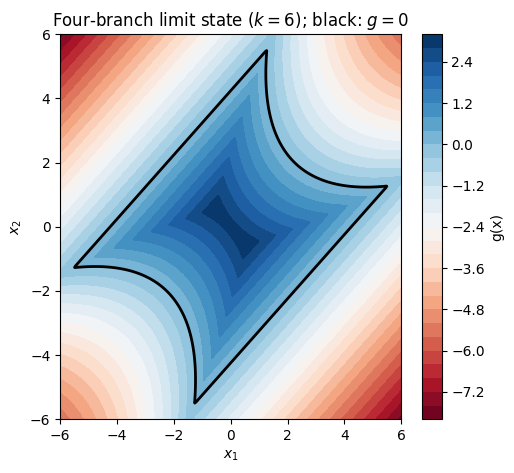

In [3]:
xx, yy = np.meshgrid(np.linspace(-6, 6, 300), np.linspace(-6, 6, 300))
G = problem(np.column_stack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(5.5, 5))
cf = ax.contourf(xx, yy, G, levels=30, cmap="RdBu")
ax.contour(xx, yy, G, levels=[0.0], colors="k", linewidths=2)
plt.colorbar(cf, label="g(x)")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("Four-branch limit state ($k=6$); black: $g=0$")
plt.show()

## 2. Run AK-MCS with three learning functions

Identical Monte Carlo population, initial design and GP prior across methods (the seed fixes everything). Budgets are kept small so the notebook runs in a couple of minutes — the article uses larger populations and 50 replications (see `scripts/run_experiments.py`).

In [10]:
def make_algo(learning, conformal=None):
    return AKMCS(
        problem=problem,
        learning=learning,
        conformal=conformal,
        gp_factory=lambda: LOOGPRegressor(kernel="matern52", noise=1e-4,
                                          training_iter=50),
        n_mc=10000, n_init=12, max_calls=60, min_iterations=5,
        track_coverage=True,   # g is analytic here, so this is cheap
    )

runs = {
    "U": make_algo("U").run(seed=3),
    "C2-J+GP": make_algo(ConformalC2(pf_gap_tol=1e-3), "j+gp").run(seed=3),
    "C2-J+minmax-GP": make_algo(ConformalC2(pf_gap_tol=1e-3), "j-mm-gp").run(seed=3),
}
for name, r in runs.items():
    bounds = (f" in [{r.pf_lower:.2e}, {r.pf_upper:.2e}]"
              if r.pf_lower is not None else "")
    print(f"{name:>16s}: Pf = {r.pf:.3e}{bounds}  "
          f"({r.n_calls} g-calls, converged={r.converged})")

               U: Pf = 1.100e-03  (23 g-calls, converged=True)
         C2-J+GP: Pf = 3.600e-03 in [3.20e-03, 4.10e-03]  (47 g-calls, converged=True)
  C2-J+minmax-GP: Pf = 3.600e-03 in [3.20e-03, 4.10e-03]  (52 g-calls, converged=True)


## 3. Convergence of $\widehat{P}_f$ and certified bounds

The C² variants additionally carry the conformal bounds $[\widehat{P}_f^-, \widehat{P}_f^+]$; their gap is the stopping criterion.

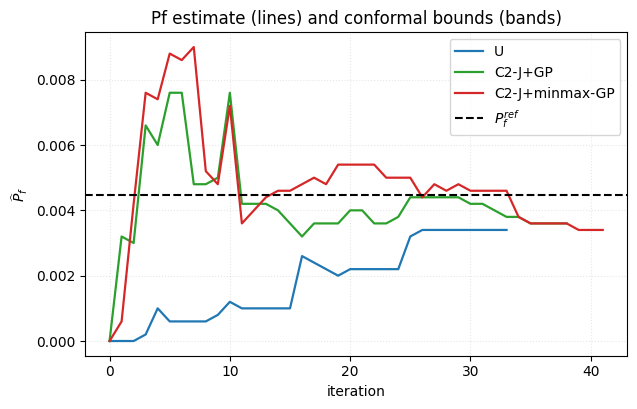

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.2))
colors = {"U": "tab:blue", "C2-J+GP": "tab:green", "C2-J+minmax-GP": "tab:red"}
for name, r in runs.items():
    h = r.history_array()           # n_calls, pf_hat, pf_lo, pf_up, gap, cov, t
    it = np.arange(h.shape[0])
    ax.plot(it, h[:, 1], color=colors[name], label=name, lw=1.6)
    #if np.any(np.isfinite(h[:, 2])):
    #    ax.fill_between(it, h[:, 2], h[:, 3], color=colors[name], alpha=0.15)
ax.axhline(problem.pf_ref, color="k", ls="--", label="$P_f^{ref}$")
ax.set_xlabel("iteration"); ax.set_ylabel(r"$\widehat{P}_f$")
ax.legend(); ax.grid(alpha=0.3, ls=":")
ax.set_title("Pf estimate (lines) and conformal bounds (bands)")
plt.show()

## 4. Where do the methods place their evaluations?

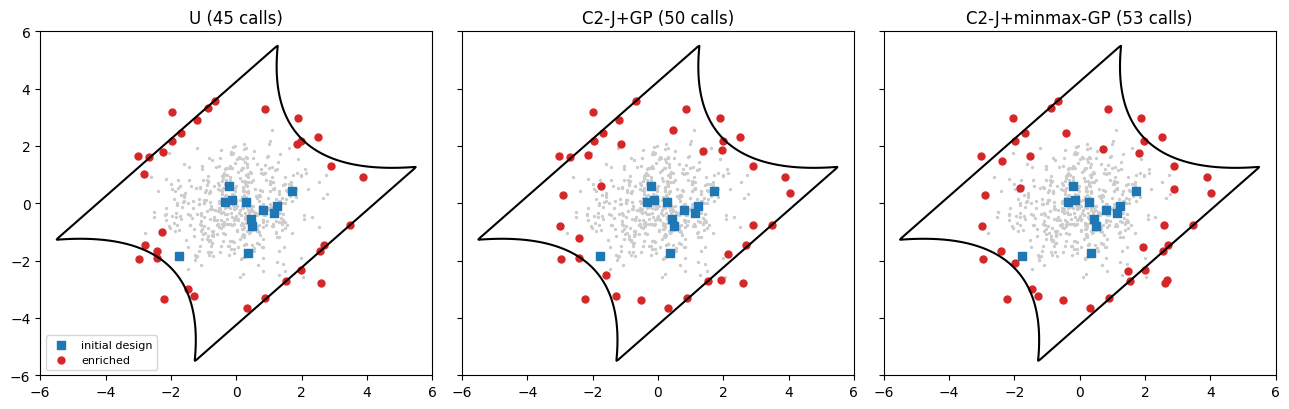

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharex=True, sharey=True)
for ax, (name, r) in zip(axes, runs.items()):
    ax.contour(xx, yy, G, levels=[0.0], colors="k", linewidths=1.5)
    S = r.S_raw
    ax.scatter(S[::10, 0], S[::10, 1], s=2, color="0.8", zorder=0)
    # training inputs are standardized; map back to raw coordinates
    mu_s, sd_s = S.mean(0), S.std(0)
    Xr = r.X_train * sd_s + mu_s
    ax.scatter(Xr[:12, 0], Xr[:12, 1], marker="s", c="tab:blue", s=35,
               label="initial design")
    ax.scatter(Xr[12:, 0], Xr[12:, 1], marker="o", c="tab:red", s=25,
               label="enriched")
    ax.set_title(f"{name} ({r.n_calls} calls)"); ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
axes[0].legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()

## 5. Conformal intervals and the coverage diagnostic

The J+GP / J-minmax-GP intervals are built from the $n$ leave-one-out predictors *at the test point* (genuine Jackknife+, closed form). The empirical coverage on the Monte Carlo population is tracked during the run — a validity diagnostic with no analogue for U/EFF. Active enrichment breaks exchangeability, so a moderate drift from the nominal level is expected and discussed in the paper.

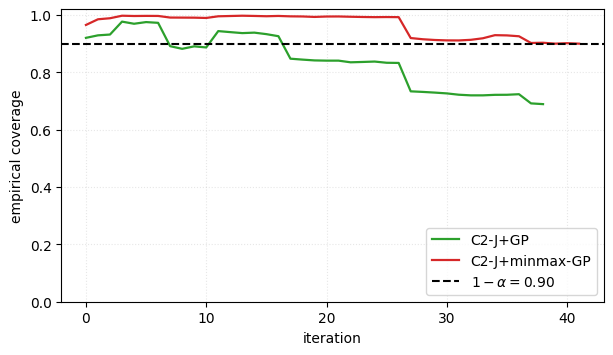

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.8))
for name in ("C2-J+GP", "C2-J+minmax-GP"):
    h = runs[name].history_array()
    ax.plot(np.arange(h.shape[0]), h[:, 5], color=colors[name], label=name, lw=1.6)
ax.axhline(0.9, color="k", ls="--", label=r"$1-\alpha=0.90$")
ax.set_ylim(0, 1.02); ax.set_xlabel("iteration"); ax.set_ylabel("empirical coverage")
ax.legend(loc="lower right"); ax.grid(alpha=0.3, ls=":")
plt.show()

In [8]:
# A standalone conformal regressor, outside the active-learning loop:
rng = np.random.default_rng(0)
X = rng.standard_normal((40, 2)); y = problem(X)
Xt = rng.standard_normal((1000, 2)); yt = problem(Xt)

gp = LOOGPRegressor(kernel="matern52", noise=1e-4).fit(X, y)
for cls in (JPlusGP, JMinmaxGP):
    conf = cls(estimator=gp, alpha=0.1, prefit=True).fit(X, y)
    itv = conf.predict_interval(Xt)
    cov = np.mean((itv[:, 0] <= yt) & (yt <= itv[:, 1]))
    print(f"{cls.__name__:>10s}: coverage = {cov:.3f}, "
          f"median width = {np.median(itv[:,1]-itv[:,0]):.3f}")

   JPlusGP: coverage = 0.818, median width = 0.182
 JMinmaxGP: coverage = 0.944, median width = 0.273


## 6. Going further

- **Batch enrichment** for parallel solver calls: `ConformalC2(batch_q=4, batch_delta=0.5)` (greedy farthest-radius selection).
- **Custom learning functions**: subclass `LearningFunction` — see the README.
- **Article-scale experiments**: `python scripts/run_experiments.py --n-jobs 16`, then `python scripts/make_figures.py`.